# Análisis de datos
## Clase 3 y 4
### Actividad individual N°3 - Dataset "Estadisticas climaticas normales periodo 1991-2020"

In [160]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Pagina de origen del dataset : https://ws2.smn.gob.ar/

##### Se descarga "Estadisticas climaticas normales" y "Listado de estaciones meteorologicas", se los fusiona en un solo archivo .xlsx llamado "Estadisticas climaticas normales periodo 1991-2020.xlsx" donde cada hoja representa cada dataset.

### Analizamos hoja numero 1 "Estadisticas"

In [104]:
#se crea un Dataframe con el dataset de la primer hoja
df_estadisticas = pd.read_excel("Estadisticas climaticas normales periodo 1991-2020.xlsx", sheet_name="Estadisticas")

#Se muestra el resultado
df_estadisticas.head()

,ESTACION,PARAMETRO,ENERO,FEBRERO,MARZO,ABRIL,MAYO,JUNIO,JULIO,AGOSTO,SEPTIEMBRE,OCTUBRE,NOVIEMBRE,DICIEMBRE
0,LA QUIACA OBSERVATORIO,Temperatura (°C),13.2,13,12.8,11.3,7.3,4.8,4.5,7,10,12.4,13.4,13.9
1,LA QUIACA OBSERVATORIO,Temperatura máxima (°C),20.6,20.4,20.6,20.3,17.8,16.3,16.1,18,20,21.7,22.5,22.2
2,LA QUIACA OBSERVATORIO,Temperatura mínima (°C),7.7,7.6,6.6,3.1,-2.5,-5.7,-6.2,-4,-0.4,3.3,5.5,7.3
3,LA QUIACA OBSERVATORIO,Humedad relativa (%),62.6,63.2,60.3,46,32.6,27.4,25.7,26.7,32.1,42.4,48.6,55.8
4,LA QUIACA OBSERVATORIO,Velocidad del Viento (km/h) (2011-2020),6.5,6.8,6.7,5.5,4.8,5.5,5.9,6.7,7.9,7.9,7.7,7.1


### Analizamos hoja numero 2 "Estaciones"

In [105]:
#se crea un Dataframe con el dataset de la segunda hoja
df_estaciones = pd.read_excel("Estadisticas climaticas normales periodo 1991-2020.xlsx", sheet_name="Estaciones")

#Se muestra el resultado
df_estaciones.head()

,NOMBRE,PROVINCIA,LATITUD (grados),LATITUD (minutos),LONGITUD (grados),LONGITUD (minutos),ALTURA [m],NUMERO,NUMERO OACI
0,BASE BELGRANO II,ANTARTIDA,-77,52,-34,37,256,89034,SAYB
1,BASE CARLINI (EX JUBANY),ANTARTIDA,-62,14,-58,39,11,89053,SAYJ
2,BASE ESPERANZA,ANTARTIDA,-63,23,-56,59,24,88963,SAYE
3,BASE MARAMBIO,ANTARTIDA,-64,14,-56,37,198,89055,SAWB
4,BASE ORCADAS,ANTARTIDA,-60,44,-44,44,12,88968,SAYO


## REGION SELECCIONADA -->"CUYO"
* MENDOZA
* SAN JUAN
* SAN LUIS
* LA RIOJA

In [106]:
#Vamos a convertir todas los valores de estacion del dataframe "estadisticas" y "estaciones" a mayusculas, sin acento y sin diéresis 
#para no generar confusiones.
df_estaciones['NOMBRE'] = df_estaciones['NOMBRE'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.upper()
df_estadisticas['ESTACION'] = df_estadisticas['ESTACION'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.upper()

In [107]:
estaciones_region = df_estaciones[df_estaciones['PROVINCIA'].isin(['MENDOZA', 'SAN JUAN', 'SAN LUIS', 'LA RIOJA'])]
cantidad_de_estaciones = len(estaciones_region)
print(f'La cantidad de estaciones meteorologicas dentro de esta region son: {cantidad_de_estaciones}')

La cantidad de estaciones meteorologicas dentro de esta region son: 15


In [108]:
#Se verifica si la columna a evaluar contiene algun valor nulo o sin datos validos.
total_nulos = df_estaciones['ALTURA [m]'].isnull().sum()
print(total_nulos)

0


In [109]:
altura_media_estaciones_region = estaciones_region['ALTURA [m]'].mean()
print(f'La altura media de las estaciones de la region es: {altura_media_estaciones_region:.2f} [m]')

La altura media de las estaciones de la region es: 822.67 [m]


In [110]:
df_filtro_media_t = df_estadisticas[(df_estadisticas['ESTACION'].isin(estaciones_region['NOMBRE'])) & (df_estadisticas['PARAMETRO'] == 'Temperatura (°C)')]
df_filtro_media_t = df_filtro_media_t.drop(columns=['ESTACION', 'PARAMETRO'])
media_total = df_filtro_media_t.values.mean()
print(f'La temperatura media de la region es: {media_total:.2f} [°C]')

La temperatura media de la region es: 17.06 [°C]


In [111]:
df_filtro_desvio_estandar = df_estadisticas[(df_estadisticas['ESTACION'].isin(estaciones_region['NOMBRE'])) & (df_estadisticas['PARAMETRO'] == 'Temperatura (°C)')]
df_filtro_desvio_estandar = df_filtro_desvio_estandar.drop(columns=['ESTACION', 'PARAMETRO'])
desvio_estandar = df_filtro_desvio_estandar.values.std()
print(f'El desvio estandar de la temperatura en la region es: {desvio_estandar:.2f} [°C]')

El desvio estandar de la emperatura en la region es: 6.27 [°C]


In [126]:
df_filtro_media_p = df_estadisticas[(df_estadisticas['ESTACION'].isin(estaciones_region['NOMBRE'])) & (df_estadisticas['PARAMETRO'] == 'Precipitación (mm)')]
df_filtro_media_p = df_filtro_media_p.drop(columns=['ESTACION', 'PARAMETRO'])
df_filtro_media_p = df_filtro_media_p.apply(pd.to_numeric, errors='coerce')
df_media = df_filtro_media_p.mean(axis=0) 
print(f'El mes con mayor precipitacion es: "{df_media.idxmax()}"')

El mes con mayor precipitacion es: "ENERO"


In [143]:
df_filtro_media_t = df_estadisticas[(df_estadisticas['ESTACION'].isin(estaciones_region['NOMBRE'])) & (df_estadisticas['PARAMETRO'] == 'Temperatura (°C)')]
df_filtro_media_t_limpio = df_filtro_media_t.drop(columns=['ESTACION', 'PARAMETRO'])
df_media = df_filtro_media_t_limpio.mean(axis=1) 
df_filtro_media_t = pd.concat([df_filtro_media_t, df_media.rename('MEDIA TEMPERATURA')], axis=1)
df_filtro_media_t
region_temp_maxima = df_filtro_media_t.loc[df_filtro_media_t['MEDIA TEMPERATURA'].idxmax(), 'ESTACION']
print(f'La estacion con mayor temperatura media es: "{region_temp_maxima}"')

La estacion con mayor temperatura media es: "LA RIOJA AERO"


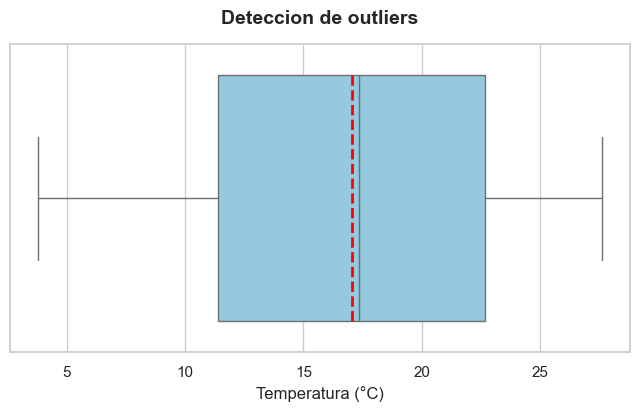

In [169]:
df_parametro = df_estadisticas[(df_estadisticas['ESTACION'].isin(estaciones_region['NOMBRE'])) & (df_estadisticas['PARAMETRO'] == 'Temperatura (°C)')]
df_parametro = df_parametro.drop(columns=['ESTACION', 'PARAMETRO'])
df_parametro = df_parametro.apply(pd.to_numeric, errors='coerce')
df_serie_parametro = pd.Series(df_parametro.values.flatten())

# Se establece un fondo de grilla blanco
sns.set_theme(style="whitegrid")

#Creamos la figura, le asignamos el color a la caja, que se muestre la media con una linea roja y espaciada.
plt.figure(figsize=(8, 4))
ax = sns.boxplot(x=df_serie_parametro, color="skyblue", showmeans=True, meanline=True, meanprops={"linestyle": "--", "linewidth": 2, "color": "red"})

#Cambiamos el texto de los ejes y el titulo
ax.set_title('Deteccion de outliers', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Temperatura (°C)', fontsize=12)
plt.show()

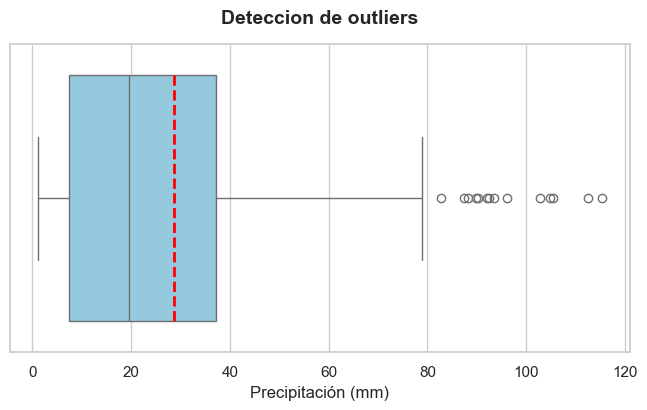

In [170]:
df_parametro = df_estadisticas[(df_estadisticas['ESTACION'].isin(estaciones_region['NOMBRE'])) & (df_estadisticas['PARAMETRO'] == 'Precipitación (mm)')]
df_parametro = df_parametro.drop(columns=['ESTACION', 'PARAMETRO'])
df_parametro = df_parametro.apply(pd.to_numeric, errors='coerce')
df_serie_parametro = pd.Series(df_parametro.values.flatten())

# Se establece un fondo de grilla blanco
sns.set_theme(style="whitegrid")

#Creamos la figura, le asignamos el color a la caja, que se muestre la media con una linea roja y espaciada.
plt.figure(figsize=(8, 4))
ax = sns.boxplot(x=df_serie_parametro, color="skyblue", showmeans=True, meanline=True, meanprops={"linestyle": "--", "linewidth": 2, "color": "red"})

#Cambiamos el texto de los ejes y el titulo
ax.set_title('Deteccion de outliers', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Precipitación (mm)', fontsize=12)
plt.show()

In [182]:
#Defino un dataframe donde solo conservo las columnas que me interesan en este analisis, en este caso para la altura de las estaciones.
altura_estaciones_region = estaciones_region.loc[:,['NOMBRE', 'PROVINCIA','ALTURA [m]']]
altura_estaciones_region

#Defino un dataframe donde solo conservo las columnas que me interesan en este analisis, en este caso para la temperatura media de las estaciones
df_filtro_media_t = df_estadisticas[(df_estadisticas['ESTACION'].isin(estaciones_region['NOMBRE'])) & (df_estadisticas['PARAMETRO'] == 'Temperatura (°C)')]
df_filtro_media_t_limpio = df_filtro_media_t.drop(columns=['ESTACION', 'PARAMETRO'])
df_media = df_filtro_media_t_limpio.mean(axis=1) 
df_filtro_media_t = pd.concat([df_filtro_media_t, df_media.rename('TEMPERATURA MEDIA')], axis=1)
temperatura_media_estaciones_region = df_filtro_media_t.loc[:,['ESTACION', 'PARAMETRO','TEMPERATURA MEDIA']]
temperatura_media_estaciones_region

#Hago un merge con ambos dataframe para vincular la temperatura media de cada estacion con la altura de la misma
df_coincidencias = pd.merge(altura_estaciones_region, temperatura_media_estaciones_region, left_on='NOMBRE', right_on='ESTACION', how='inner')

df_coincidencias

,NOMBRE,PROVINCIA,ALTURA [m],ESTACION,PARAMETRO,TEMPERATURA MEDIA
0,CHAMICAL AERO,LA RIOJA,461,CHAMICAL AERO,Temperatura (°C),19.875
1,CHILECITO AERO,LA RIOJA,947,CHILECITO AERO,Temperatura (°C),18.591667
2,LA RIOJA AERO,LA RIOJA,438,LA RIOJA AERO,Temperatura (°C),20.266667
3,MALARGUE AERO,MENDOZA,1425,MALARGUE AERO,Temperatura (°C),12.141667
4,MENDOZA AERO,MENDOZA,704,MENDOZA AERO,Temperatura (°C),17.341667
5,MENDOZA OBSERVATORIO,MENDOZA,827,MENDOZA OBSERVATORIO,Temperatura (°C),16.25
6,SAN MARTIN (MZA),MENDOZA,653,SAN MARTIN (MZA),Temperatura (°C),16.816667
7,SAN RAFAEL AERO,MENDOZA,748,SAN RAFAEL AERO,Temperatura (°C),15.383333
8,JACHAL,SAN JUAN,1175,JACHAL,Temperatura (°C),16.766667
9,SAN JUAN AERO,SAN JUAN,598,SAN JUAN AERO,Temperatura (°C),18.025


In [185]:
#Se calcula la correlacion de spearman entre la altura de las estaciones y su temperatura media de las mismas.
correlacion = df_coincidencias['ALTURA [m]'].corr(df_coincidencias['TEMPERATURA MEDIA'], method='spearman')

print(f"El valor de correlación de Spearman es: {correlacion:.2f}")

El valor de correlación de Spearman es: -0.57


In [191]:
#Defino un dataframe donde solo conservo las columnas que me interesan en este analisis, en este caso para la altura de las estaciones.
altura_estaciones_region = estaciones_region.loc[:,['NOMBRE', 'PROVINCIA']]
altura_estaciones_region

#Defino un dataframe donde solo conservo las columnas que me interesan en este analisis, en este caso para la temperatura media de las estaciones
df_filtro_media_t = df_estadisticas[(df_estadisticas['ESTACION'].isin(estaciones_region['NOMBRE'])) & (df_estadisticas['PARAMETRO'] == 'Precipitación (mm)')]
df_filtro_media_t_limpio = df_filtro_media_t.drop(columns=['ESTACION', 'PARAMETRO'])
df_filtro_media_t_limpio = df_filtro_media_t_limpio.apply(pd.to_numeric, errors='coerce')
df_media = df_filtro_media_t_limpio.mean(axis=1) 
df_filtro_media_t = pd.concat([df_filtro_media_t, df_media.rename('PRECIPITACION MEDIA')], axis=1)
temperatura_media_estaciones_region = df_filtro_media_t.loc[:,['ESTACION', 'PARAMETRO','PRECIPITACION MEDIA']]
temperatura_media_estaciones_region

#Hago un merge con ambos dataframe para vincular la temperatura media de cada estacion con la altura de la misma
df_coincidencias = pd.merge(altura_estaciones_region, temperatura_media_estaciones_region, left_on='NOMBRE', right_on='ESTACION', how='inner')

df_coincidencias

,NOMBRE,PROVINCIA,ESTACION,PARAMETRO,PRECIPITACION MEDIA
0,CHAMICAL AERO,LA RIOJA,CHAMICAL AERO,Precipitación (mm),38.341667
1,CHILECITO AERO,LA RIOJA,CHILECITO AERO,Precipitación (mm),8.357143
2,LA RIOJA AERO,LA RIOJA,LA RIOJA AERO,Precipitación (mm),33.908333
3,MALARGUE AERO,MENDOZA,MALARGUE AERO,Precipitación (mm),26.716667
4,MENDOZA AERO,MENDOZA,MENDOZA AERO,Precipitación (mm),19.833333
5,MENDOZA OBSERVATORIO,MENDOZA,MENDOZA OBSERVATORIO,Precipitación (mm),22.250000
6,SAN MARTIN (MZA),MENDOZA,SAN MARTIN (MZA),Precipitación (mm),21.883333
7,SAN RAFAEL AERO,MENDOZA,SAN RAFAEL AERO,Precipitación (mm),30.241667
8,JACHAL,SAN JUAN,JACHAL,Precipitación (mm),10.283333
9,SAN JUAN AERO,SAN JUAN,SAN JUAN AERO,Precipitación (mm),7.550000
